***Proyecto Final: Telecomunicaciones: identificar operadores ineficaces***

El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.

- Lleva a cabo el análisis exploratorio de datos
- Identificar operadores ineficaces
- Prueba las hipótesis estadísticas

In [ ]:
#Importar librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

In [ ]:
#Cargar dataset
telecom_data = pd.read_csv('/datasets/telecom_dataset_us.csv')
clients_data = pd.read_csv('/datasets/telecom_clients_us.csv')


In [ ]:
#Unir dataser por user_id
df = telecom_data.merge(clients_data, on='user_id', how='left')

#Ver información general
print(df.info())
print()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53902 entries, 0 to 53901
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
 9   tariff_plan          53902 non-null  object 
 10  date_start           53902 non-null  object 
dtypes: bool(1), float64(1), int64(4), object(5)
memory usage: 4.6+ MB
None

   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-0

El objetivo principal es identificar los operadores ineficaces, por ende, si no se conoce el id del operador no sería válido y se puede observar que es la única columna con datos nulos, sin embargo, sería incorrecto eliminarlos ya que si una persona llama y no le contestan el sistema nunca le asignaria un ID, es por eso que creare un DataFrame aparte con los operadores que si tienen ID.

In [ ]:
df_operators = df.dropna(subset=['operator_id']).copy()
#Convertir a entero
df_operators['operator_id']=df_operators['operator_id'].astype(int)

In [ ]:
#Analizar llamadas sin operador
df_null_operators = df[df['operator_id'].isnull()]

#Ver que clientes tienen más llamadas sin operador
nulls_by_user = df_null_operators.groupby('user_id')['calls_count'].sum().sort_values(ascending=False)
print('Top 10 clientes con más llamadas sin operador: ')
print(nulls_by_user.head(10))

Top 10 clientes con más llamadas sin operador: 
user_id
167626    25915
168361    18925
168252     6792
166405     6080
166582     5251
168187     2639
167071     2523
167650     2126
167189     2106
167521     2017
Name: calls_count, dtype: int64


In [ ]:
#Analizar la dirección de las llamadas nulas
null_direction = df_null_operators['direction'].value_counts(normalize=True)*100
print('Distribución por dirección en llamadas nulas')
print(null_direction)

Distribución por dirección en llamadas nulas
in     97.552619
out     2.447381
Name: direction, dtype: float64


In [ ]:
null_internal = df_null_operators['internal'].value_counts(normalize=True)*100
print('¿Las llamadas nulas eran internas?')
print(null_internal)

¿Las llamadas nulas eran internas?
False    95.625385
True      4.374615
Name: internal, dtype: float64


In [ ]:
#Verificar si los nulos coiciden con llamadas pérdidas
null_missed = df_null_operators['is_missed_call'].value_counts(normalize=True)*100
print('¿Las llamadas nulas eran llamadas pérdidas?')
print(null_missed)

¿Las llamadas nulas eran llamadas pérdidas?
True     98.507097
False     1.492903
Name: is_missed_call, dtype: float64


En conclusión, trabajare con el dataframe que tiene operadores, más sin embargo, es importante recalcar que el sistema pierde miles de llamadas antes de que siquiera lleguen a un operador, los nulos no son errores del sistema sino llamadas no atendidas.

In [ ]:
#Convertir fechas de DataFrame sin operadores nulos
df_operators['date'] = pd.to_datetime(df_operators['date'])

In [ ]:
#Calcular el tiempo de espera
#total_call_duration incluye el tiempo de espera y call_duration solo el tiempo de conversación
df_operators['waiting_time'] = df_operators['total_call_duration'] - df_operators['call_duration']

In [ ]:
#Resumir la actividad de cada operador
operator_performance = df_operators.groupby('operator_id').agg({
    'is_missed_call':'sum',
    'calls_count':'sum',
    'waiting_time':'mean',
    'call_duration':'sum',
    'direction':lambda x:(x=='out').sum()
}).reset_index()

operator_performance.columns=[
    'operator_id','missed_calls','total_calls','avg_waiting_time','total_talk_time','outbound_calls'
]

In [ ]:
#Ver tasas de error
operator_performance['missed_rate'] = operator_performance['missed_calls'] / operator_performance['total_calls']
print(operator_performance.head())


   operator_id  missed_calls  total_calls  avg_waiting_time  total_talk_time  \
0       879896            50         1131        110.671875            83261   
1       879898           100         7974        450.087649           278878   
2       880020             7           54         15.181818             2290   
3       880022            33          219         57.565789            18304   
4       880026            94         2439        121.171717           169674   

   outbound_calls  missed_rate  
0             105     0.044209  
1             187     0.012541  
2              14     0.129630  
3              68     0.150685  
4             179     0.038540  


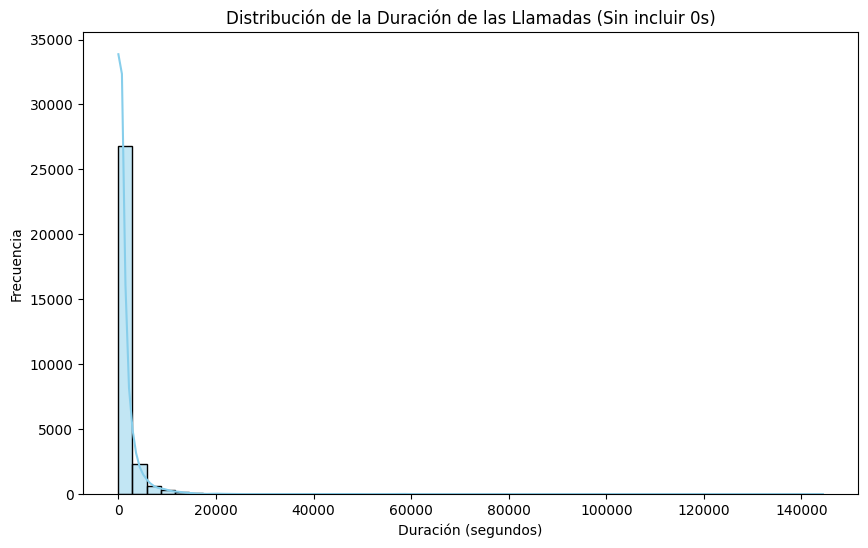

In [ ]:
#Histograma duración de llamadas
plt.figure(figsize=(10, 6))
sns.histplot(df_operators[df_operators['call_duration'] > 0]['call_duration'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de la Duración de las Llamadas (Sin incluir 0s)')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.show()

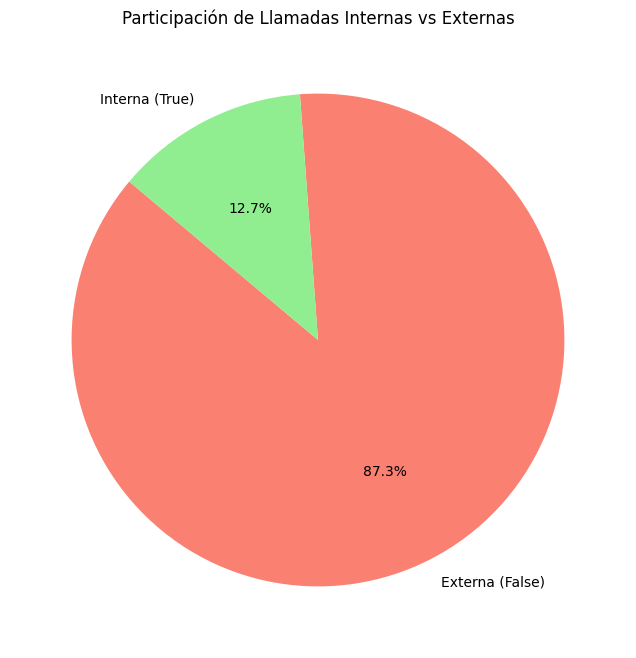

In [ ]:
#Participación de llamadas internas vs externas
# Contamos los valores de la columna 'internal'
internal_counts = df_operators['internal'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(internal_counts, labels=['Externa (False)', 'Interna (True)'], autopct='%1.1f%%', startangle=140, colors=['salmon', 'lightgreen'])
plt.title('Participación de Llamadas Internas vs Externas')
plt.show()

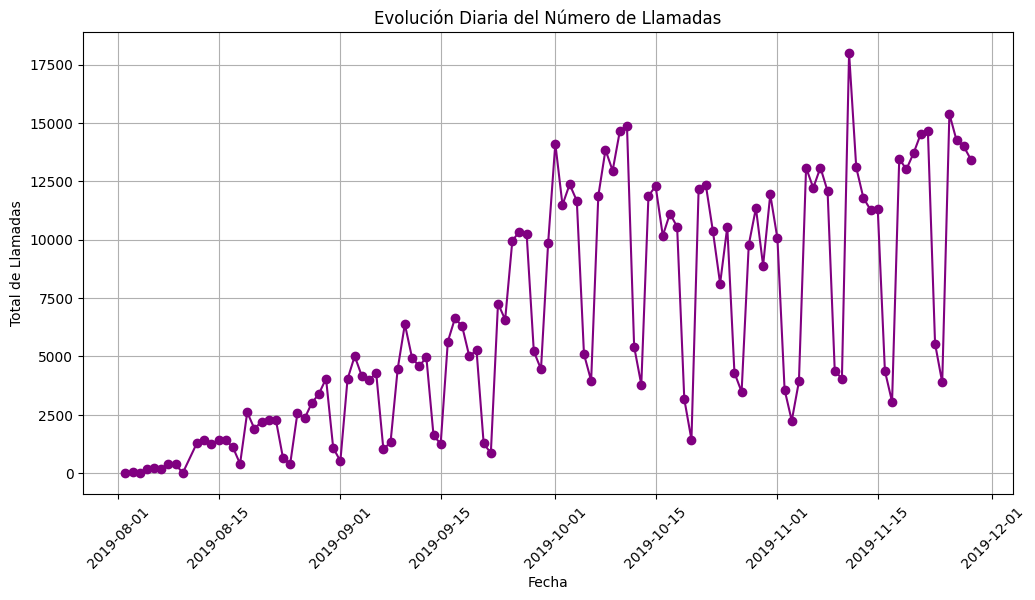

In [ ]:
#Número de llamadas por día
# Agrupar por fecha y contar llamadas
calls_per_day = df_operators.groupby(df_operators['date'].dt.date)['calls_count'].sum()

plt.figure(figsize=(12, 6))
calls_per_day.plot(kind='line', marker='o', color='purple')
plt.title('Evolución Diaria del Número de Llamadas')
plt.xlabel('Fecha')
plt.ylabel('Total de Llamadas')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

- La gran mayoría de llamadas son muy cortas, lo que podría significar problemas técnicos, o llamadas a clientes que apenas contestan cuelgan, o un operador que hace constantes llamadas cortas para alcanzar su tope de llamadas.
- Las llamadas son principalmente externas, lo que significa que pueden ser de atención al cliente o de ventas, por ende, la ineficacia del operador afecta directamente la imagen de la compañia
- En el tercer gráfico se observa un crecimiento explosivo, en agosto casi no había actividad y en noviembre el volumen es altísimo.

Segun los gráficos anteriores, se considerarán los siguientes criterios para categorizar un operador como ineficiente:
- Un operador es ineficaz si su tasa de llamadas perdidas es mayor al percentil 80 de toda la empresa
- Si su tiempo de espera promedio supera los 30 segundos.
- Si un operador que suponemos que sea de ventas hace menos de 5 llamadas al día.

In [ ]:
# Definir los límites basados en los datos
limit_waiting = operator_performance['avg_waiting_time'].quantile(0.80)
limit_missed = operator_performance['missed_rate'].quantile(0.80)

print(f"Umbral de espera (seg): {limit_waiting:.2f}")
print(f"Umbral de tasa de perdidas: {limit_missed:.2%}")

Umbral de espera (seg): 223.83
Umbral de tasa de perdidas: 14.29%


In [ ]:
#Identificar operadores ineficientes
# Creamos la columna de ineficacia
operator_performance['is_inefficient'] = (
    (operator_performance['avg_waiting_time'] > limit_waiting) |
    (operator_performance['missed_rate'] > limit_missed)
)

# Veamos cuántos resultaron ineficaces
inefficient_count = operator_performance['is_inefficient'].sum()
total_ops = len(operator_performance)

print(f"Se identificaron {inefficient_count} operadores ineficaces de un total de {total_ops}.")

Se identificaron 435 operadores ineficaces de un total de 1092.


*Hipotesis*
Probar si plan de tarifas del cliente (tariff_plan) influye en el comportamiento de los operadores.

- H0: No hay diferencia en el tiempo de espera promedio entre el Plan A y el Plan C.
- H1: Hay una diferencia significativa en el tiempo de espera entre el Plan A y el Plan C.

In [ ]:
#Unir plan de tarifas al operador
op_tariffs = df_operators.groupby('operator_id')['tariff_plan'].first().reset_index()
ops_perf_with_tariff = operator_performance.merge(op_tariffs, on='operator_id')

# Separar los tiempos de espera por plan (ejemplo entre Plan A y C)
plan_a_waiting = ops_perf_with_tariff[ops_perf_with_tariff['tariff_plan'] == 'A']['avg_waiting_time']
plan_c_waiting = ops_perf_with_tariff[ops_perf_with_tariff['tariff_plan'] == 'C']['avg_waiting_time']

#Prueba t de Student
alpha = 0.05
results = st.ttest_ind(plan_a_waiting, plan_c_waiting)

print(f'Valor p: {results.pvalue}')

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: hay una diferencia significativa.")
else:
    print("No podemos rechazar la hipótesis nula: no hay evidencia de diferencia.")

Valor p: 7.110756898677928e-13
Rechazamos la hipótesis nula: hay una diferencia significativa.


- El plan de tarifas que tiene un cliente afecta directamente el rendimiento de sus operadores.
- Podría pensarse que algunos operadores podrían parecer "ineficaces" simplemente porque están en un plan de tarifas que maneja un volumen de llamadas más pesado o con menos recursos técnicos

In [ ]:
# Filtramos: Solo operadores con más de 20 llamadas totales
ranking_real = operator_performance[operator_performance['total_calls'] >= 20].copy()

# Ahora sí, ordenamos por los más ineficaces
ranking_real = ranking_real.sort_values(by=['missed_rate', 'avg_waiting_time'], ascending=False)

print("Ranking Profesional de Ineficacia (Mín. 20 llamadas):")
print(ranking_real[['operator_id', 'missed_rate', 'avg_waiting_time', 'total_calls']].head(10))



Ranking Profesional de Ineficacia (Mín. 20 llamadas):
     operator_id  missed_rate  avg_waiting_time  total_calls
113       894232     0.380952         23.071429           21
7         881278     0.350000          9.750000           20
112       894230     0.333333         20.416667           21
111       894226     0.320000         28.583333           25
742       939212     0.300000         12.470588           20
68        891156     0.291667         25.666667           24
888       947610     0.291667         16.375000           24
95        892530     0.285714         38.176471           21
998       957022     0.285714         25.000000           21
272       906392     0.275000         23.216216           80


***CONCLUSIONES***

- El servicio ha experimentado un aumento explosivo en el volumen de llamadas entre agosto y noviembre de 2019. Este crecimiento es positivo para el negocio, pero ha puesto a prueba la capacidad de respuesta de los operadores.
- El 98.5% de los valores nulos en los IDs de operadores corresponden a llamadas perdidas. Esto indica que hay una cantidad masiva de clientes que ni siquiera logran ser atendidos, lo que sugiere una necesidad urgente de contratar más personal.
- Usando el percentil 80 se logra aislar al 20% de los operadores con el desempeño más bajo en términos de tiempos de espera y tasas de abandono. Este enfoque permite a la empresa intervenir capacitando o reasignando, en lugar de penalizar a todo el equipo.